# Olist Delivery Performance Analysis

This notebook analyzes delivery performance by comparing estimated vs actual delivery dates and evaluates delay patterns.

In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.io as pio
pio.renderers.default = "png"


## Hypothesis

- H0: Late delivery has no impact on review score.
- H1: Late delivery decreases review score.

In [2]:
orders = pd.read_csv("olist_orders_dataset.csv")
orders

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00
...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00


In [3]:
orders.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'order_approved_at', 'order_delivered_carrier_date',
       'order_delivered_customer_date', 'order_estimated_delivery_date'],
      dtype='str')

In [4]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB


In [5]:
# we are gonna turn date columns into real date:
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'], errors = 'coerce')
orders['order_approved_at'] = pd.to_datetime(orders['order_approved_at'], errors = 'coerce')
orders['order_delivered_carrier_date'] = pd.to_datetime(orders['order_delivered_carrier_date'], errors = 'coerce')
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'], errors = 'coerce')
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'], errors = 'coerce')
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  str           
 1   customer_id                    99441 non-null  str           
 2   order_status                   99441 non-null  str           
 3   order_purchase_timestamp       99441 non-null  datetime64[us]
 4   order_approved_at              99281 non-null  datetime64[us]
 5   order_delivered_carrier_date   97658 non-null  datetime64[us]
 6   order_delivered_customer_date  96476 non-null  datetime64[us]
 7   order_estimated_delivery_date  99441 non-null  datetime64[us]
dtypes: datetime64[us](5), str(3)
memory usage: 6.1 MB


In [6]:
# we are gonna primary key control because order_id values should be unique. we are gonna use this table as a fact table.
orders["order_id"].nunique(), len(orders)

(99441, 99441)

In [7]:
orders['order_status'].value_counts()

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [8]:
delivered_orders = orders[orders['order_status'] == 'delivered']
delivered_orders

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26
...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15


In [9]:
# we can say that operation is healty and cancellation rate is low , delivery performance analysis is significant.
delivered_orders.shape , orders.shape

((96478, 8), (99441, 8))

In [10]:
# we still have some empty values. data is not consistent.
delivered_orders.isnull().sum()

order_id                          0
customer_id                       0
order_status                      0
order_purchase_timestamp          0
order_approved_at                14
order_delivered_carrier_date      2
order_delivered_customer_date     8
order_estimated_delivery_date     0
dtype: int64

In [11]:
# as we see here we deleted all rows that order_delivered_customer_date is null.
delivered_orders = delivered_orders[delivered_orders['order_delivered_customer_date'].notna()]
delivered_orders.isnull().sum()

order_id                          0
customer_id                       0
order_status                      0
order_purchase_timestamp          0
order_approved_at                14
order_delivered_carrier_date      1
order_delivered_customer_date     0
order_estimated_delivery_date     0
dtype: int64

In [12]:
delivered_orders['delivered_time'] = delivered_orders['order_delivered_customer_date'] - delivered_orders['order_purchase_timestamp']
delivered_orders['delivered_time'] = delivered_orders['delivered_time'].dt.days
delivered_orders['delivered_time']

0         8
1        13
2         9
3        13
4         2
         ..
99436     8
99437    22
99438    24
99439    17
99440     7
Name: delivered_time, Length: 96470, dtype: int64

In [13]:
delivered_orders['delivered_time'].describe()
# min = 0  means that it is possible same day delivery
# max = 209 it is outlier so not normal 209 days delivery time.
# mean = 12  avg delivery time is 12 days
# median = 10 means that %50 of orders delivered 10 days or shorter
# %50 of orders delivered longer than 10 days
# avg ≈ median means distribution is balanced
# avg > median means there is a distorder distribution to the right 
# so some orders are too late. For example we have 209 days. it caused right skewed distrubition

count    96470.000000
mean        12.093604
std          9.551380
min          0.000000
25%          6.000000
50%         10.000000
75%         15.000000
max        209.000000
Name: delivered_time, dtype: float64

In [14]:
delivered_orders['delivery_delay'] = delivered_orders['order_delivered_customer_date'] - delivered_orders['order_estimated_delivery_date']
delivered_orders['delivery_delay'] = delivered_orders['delivery_delay'].dt.days
delivered_orders['delivery_delay'] 
# here negatif values represent earlier delivered.

0        -8
1        -6
2       -18
3       -13
4       -10
         ..
99436   -11
99437    -2
99438    -6
99439   -21
99440   -18
Name: delivery_delay, Length: 96470, dtype: int64

In [15]:
delivered_orders.loc[delivered_orders["delivery_delay"] > 0, "delivery_status"] = "Late"
delivered_orders.loc[delivered_orders["delivery_delay"] < 0, "delivery_status"] = "Early"
delivered_orders.loc[delivered_orders["delivery_delay"] == 0, "delivery_status"] = "On-time"
delivered_orders

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivered_time,delivery_delay,delivery_status
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8,-8,Early
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13,-6,Early
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9,-18,Early
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13,-13,Early
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2,-10,Early
...,...,...,...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28,8,-11,Early
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02,22,-2,Early
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27,24,-6,Early
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15,17,-21,Early


In [16]:
delivered_orders['delivery_status'].value_counts() ,delivered_orders['delivery_status'].value_counts(normalize = True)

(delivery_status
 Early      88644
 Late        6534
 On-time     1292
 Name: count, dtype: int64,
 delivery_status
 Early      0.918876
 Late       0.067731
 On-time    0.013393
 Name: proportion, dtype: float64)

In [17]:
delivery_delay = delivered_orders.loc[delivered_orders["delivery_status"] == "Late", "delivery_delay"]
delivery_delay.describe()

count    6534.000000
mean       10.620141
std        14.644955
min         1.000000
25%         3.000000
50%         7.000000
75%        13.000000
max       188.000000
Name: delivery_delay, dtype: float64

In [18]:
delivery_delay.value_counts().sort_index(ascending=False)

delivery_delay
188      1
181      1
175      1
167      1
166      1
      ... 
5      447
4      453
3      500
2      545
1      825
Name: count, Length: 115, dtype: int64

In [19]:
(delivery_delay > 30).sum() , (delivery_delay > 30).mean() * 100

(np.int64(345), np.float64(5.280073461891643))

In [20]:
delay_0_30 = delivery_delay[delivery_delay <= 30]
delay_0_30

20       11
25        9
41        7
57        1
58        7
         ..
99396     5
99397     3
99423    21
99425     2
99432     8
Name: delivery_delay, Length: 6189, dtype: int64

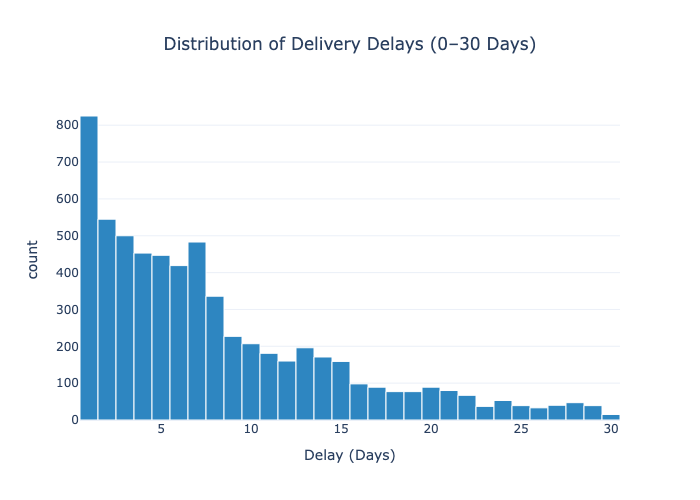

In [21]:
import plotly.express as px

fig = px.histogram(
    delay_0_30,
    nbins=30,
    title="Distribution of Delivery Delays (0–30 Days)",
    labels={"value": "Delay (Days)", "count": "Number of Orders"},
    color_discrete_sequence=["#2E86C1"]
)

fig.update_traces(
    marker_line_color="white",
    marker_line_width=1
)

fig.update_layout(
    template="plotly_white",
    title_x=0.5,
    showlegend=False
)

fig.show()

In [22]:
delivered_orders["abs_error"] = delivered_orders["delivery_delay"].abs()
mae = delivered_orders["abs_error"].mean()
mae

np.float64(13.314512283611485)

In [23]:
late_mean = delivered_orders.loc[
    delivered_orders["delivery_status"] == "Late",
    "delivery_delay"
].mean()

late_mean

np.float64(10.620140801958984)

In [24]:
early_mean = delivered_orders.loc[
    delivered_orders["delivery_status"] == "Early",
    "delivery_delay"
].mean()

early_mean

np.float64(-13.707177022697532)

## Final Insights

- 91.9% of deliveries arrive earlier than estimated, while 6.8% are late.
- Average absolute prediction error: ~13.3 days.
- Late deliveries are delayed by ~10.6 days on average.
- Early deliveries arrive ~13.7 days earlier than estimated.
- The delivery estimation system appears conservative and tends to overestimate delivery times.